<a href="https://colab.research.google.com/github/farahnda/Learning/blob/main/Visualizing_Output.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
df = pd.read_csv('pokemon.csv', encoding='unicode_escape')
df.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [25]:
types = df['Type 1'].isin(['Grass', 'Fire', 'Water'])
drop_cols = ['Type 1', 'Type 2', 'Generation', 'Legendary']
df = df[types].drop(columns=drop_cols)
df.head()

,Name,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,Bulbasaur,318,45,49,49,65,65,45
1,Ivysaur,405,60,62,63,80,80,60
2,Venusaur,525,80,82,83,100,100,80
3,VenusaurMega Venusaur,625,80,100,123,122,120,80
4,Charmander,309,39,52,43,60,50,65


In [31]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=3) # buat model kmeans, dibagi jadi 3 clusters (sekelompok serupa)
df['cluster'] = kmeans.fit_predict(df[['Attack', 'Defense']])
# ambul 2 kelompok,trus blajar cari centroid & cluster, terus masukkin ke mana, trus disimpan

centroids = kmeans.cluster_centers_ # INTI KMEANS, centroid = titik tengah cluster
# 0 => atk, 1 => def
cen_x = [i[0] for i in centroids]
# loop 3 putaran, tiap iterasi i[0] ambil angka pertama dari hasil ex: [63, 43] -> ambil 63, tris dikumpulon jadi [....] => semua koordinat X centroid
cen_y = [i[1] for i in centroids] # sama tapi y dan dia angka kedua

df['cen_x'] = df.cluster.map({0: cen_x[0], 1: cen_x[1], 2: cen_x[2]}) # pokemon now know posisi centroid clusternya
df['cen_y'] = df.cluster.map({0: cen_y[0], 1: cen_y[1], 2: cen_y[2]}) # sama tapi bagian y

colors = ['#DF2020', '#81DF20', '#2095DF'] # buat kampus warna
df['c'] = df.cluster.map({0: colors[0], 1: colors[1], 2: colors[2]}) # tiap pokemon diberi warna

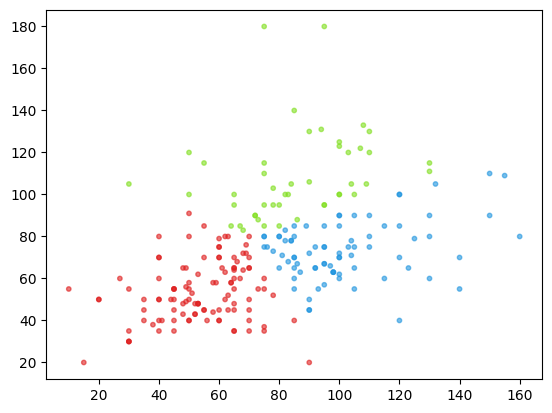

In [27]:
import matplotlib.pyplot as plt # buat gambar grafik
%matplotlib inline
plt.scatter(df.Attack, df.Defense, c=df.c, alpha=0.6, s=10)
# gambar titik pake warna c, ukuran titik sebesar 10, sb x = atk, sb y = def

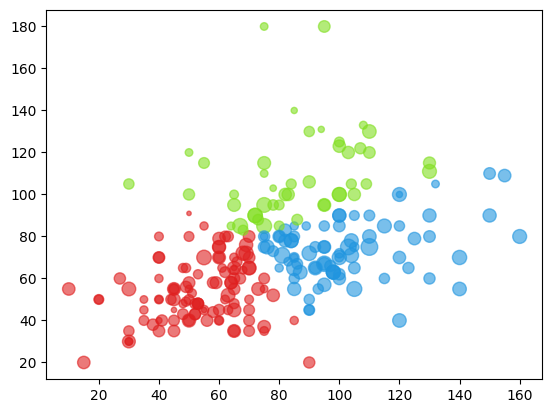

In [28]:
plt.scatter(df.Attack, df.Defense, c=df.c, alpha=0.6, s=df.Speed) # ukuran ngikut nilai speed nya

Text(0, 0.5, 'Defense')

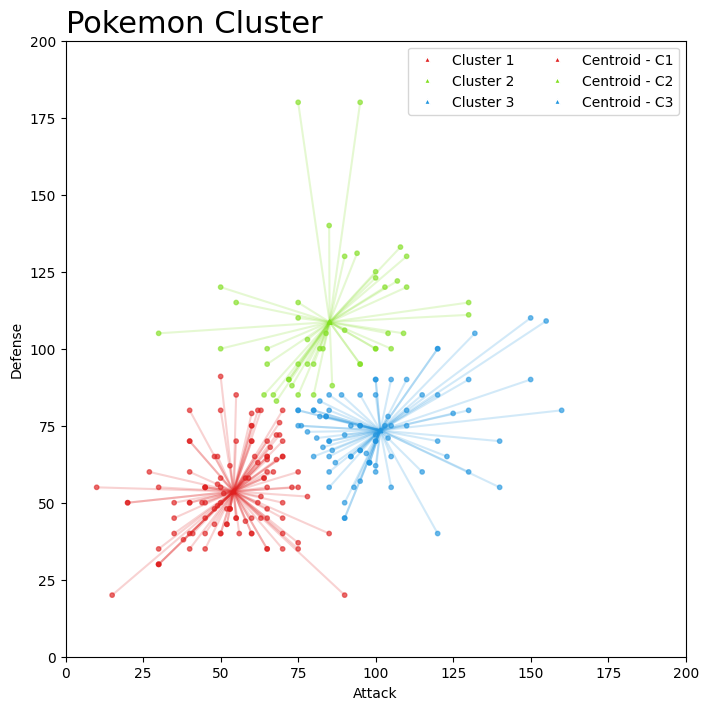

In [32]:
from matplotlib.lines import Line2D
fig, ax = plt.subplots(1, figsize = (8,8)) # buat kanvas 1 subplot 8 inch pxl
#fig = kertas, ax= area gambar

plt.scatter(df.Attack, df.Defense, c=df.c, alpha=0.6, s=10) # scatter = gambar titik sebar pokemon
plt.scatter(cen_x, cen_y, marker='^', c=colors, s=10) # gambar titik sebar centroid

for idx, val in df.iterrows(): # LOOP SEMUA POKEMON 1 PER 1
  # HASILNYA
  x = [val.Attack, val.cen_x] # x = [...., ....]
  y = [val.Defense, val.cen_y] # y = [...., ....]
  plt.plot(x, y, c=val.c, alpha=0.2) # GAMBAR GARISNYA DARI POKEMON KE CENTROID

# ## centroids
# cent_leg = [Line2D([0], [0], marker='^', color='w', label='Centroid - C{}'.format(i+1),
#                    markerfacecolor=mcolor, markersize=10) for i, mcolor in enumerate(colors)]

# Legend
# BUAT LEGEND CLUSTER
legend_elements = [Line2D([0], [0], marker='^', color='w', label='Cluster {}'.format(i+1),
                   markerfacecolor=mcolor, markersize=5) for i, mcolor in enumerate(colors)]
# BUAT LEGEND CENTROID
legend_elements.extend([Line2D([0], [0], marker='^', color='w', label='Centroid - C{}'.format(i+1),
                               markerfacecolor=mcolor, markersize=5) for i, mcolor in enumerate(colors)])
# legend_elements.extend(cent_leg)

plt.legend(handles=legend_elements, loc='upper right', ncol=2) # TAMPILIN LEGENDA DI ATAS
# x and y limits
plt.xlim(0, 200)
plt.ylim(0, 200)
# title and labels
plt.title('Pokemon Stat\n', loc='left', fontsize=22)
plt.xlabel('Attack')
plt.ylabel('Defense')